In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. Load your uploaded data files with updated paths
try:
    final_ranking = pd.read_csv('07_Optimization/6_Final_Ranking.csv')
    avg_returns = pd.read_csv('07_Optimization/S_R ratios all years.xlsx - Avg_Return_Matrix.csv')
    monthly_data = pd.read_csv('07_Optimization/S_R ratios all years.xlsx - Monthly_Detailed_Data.csv')
    sr_ratios = pd.read_csv('07_Optimization/S_R ratios all years.xlsx - SR_Ratio_Matrix.csv')
    print("Files successfully loaded!")
    print(f"Final Ranking shape: {final_ranking.shape}")
    print(f"Avg Returns shape: {avg_returns.shape}")
    print(f"Monthly Data shape: {monthly_data.shape}")
    print(f"SR Ratios shape: {sr_ratios.shape}")
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Please ensure all files are in the '07_Optimization' directory with correct names.")

# 2. Select top 10 stocks based on your Final Ranking for portfolio construction
top_n = 10
selected_stocks = final_ranking.head(top_n).copy()

ticker_mapping = {
    "Trent Ltd": "TRENT.NS",
    "Bharat Electronics Ltd": "BEL.NS",
    "Power Grid Corporation of India Ltd": "POWERGRID.NS",
    "ITC Ltd": "ITC.NS",
    "Bharti Airtel Ltd": "BHARTIAIRTEL.NS",
    "Sun Pharmaceutical Industries Ltd": "SUNPHARMA.NS",
    "Hindustan Unilever Ltd": "HINDUNILVR.NS",
    "Infosys Ltd": "INFY.NS",
    "Larsen & Toubro Ltd": "LT.NS",
    "NTPC Ltd": "NTPC.NS"
}

selected_stocks['Ticker'] = selected_stocks['Stock'].map(ticker_mapping)
selected_stocks = selected_stocks.dropna(subset=['Ticker']).reset_index(drop=True)



Files successfully loaded!
Final Ranking shape: (28, 3)
Avg Returns shape: (69, 14)
Monthly Data shape: (4368, 10)
SR Ratios shape: (28, 14)


In [21]:
print("\n" + "="*80)
print("TARGET STOCKS FOR OPTIMIZATION")
print("="*80)
print(selected_stocks[['Rank', 'Stock', 'Selection Score', 'Ticker']])
print("="*80)




TARGET STOCKS FOR OPTIMIZATION
   Rank                                Stock  Selection Score           Ticker
0     1                            Trent Ltd         0.532885         TRENT.NS
1     2               Bharat Electronics Ltd         0.532885           BEL.NS
2     3  Power Grid Corporation of India Ltd         0.458327     POWERGRID.NS
3     4                              ITC Ltd         0.440155           ITC.NS
4     5                    Bharti Airtel Ltd         0.419593  BHARTIAIRTEL.NS
5     6    Sun Pharmaceutical Industries Ltd         0.413977     SUNPHARMA.NS
6     7               Hindustan Unilever Ltd         0.389682    HINDUNILVR.NS
7     8                          Infosys Ltd         0.331505          INFY.NS
8     9                  Larsen & Toubro Ltd         0.331505            LT.NS
9    10                             NTPC Ltd         0.321673          NTPC.NS


In [22]:
tickers = selected_stocks['Ticker'].tolist()
fuzzy_scores = selected_stocks['Selection Score'].values

# Get historical returns matrix for covariance/semi-variance calculations
historical_returns = []
for t in tickers:
    # Filter historical returns for the asset
    asset_data = monthly_data[monthly_data['Ticker'] == t]['Return'].values
    if len(asset_data) == 0:
        # Fallback to general random realistic market returns if ticker format mismatches slightly
        print(f"Warning: No data found for {t}, using synthetic data")
        asset_data = np.random.normal(0.015, 0.05, 36)
    historical_returns.append(asset_data[:36]) # Using aligned historical horizon

historical_returns = np.array(historical_returns) # Shape: (Num_Assets, Time_Steps)



In [23]:
def objective_function(weights):
    """
    Calculates the Modified Sharpe Ratio (Fuzzy Return / Semi-Variance)
    Subject to Budget Constraint: Sum(Weights) = 1
    """
    # Normalize weights to strictly enforce sum = 1
    weights = weights / np.sum(weights)
    
    # Portfolio Fuzzy Return
    port_return = np.sum(weights * fuzzy_scores)
    
    # Portfolio Downside Risk (Semi-variance)
    # Calculate portfolio return time series
    port_series = np.dot(weights, historical_returns)
    mean_return = np.mean(port_series)
    
    # Underperformance deviations (Semi-variance calculation)
    downside_diff = np.minimum(port_series - mean_return, 0)
    semi_variance = np.mean(downside_diff ** 2)
    
    # Avoid zero division
    if semi_variance == 0:
        return 0
    
    # Modified Sharpe Ratio
    modified_sharpe = port_return / np.sqrt(semi_variance)
    return modified_sharpe



Running Ant Colony Optimization...
--------------------------------------------------------------------------------
Optimization complete! Best Modified Sharpe Ratio: 20.3554


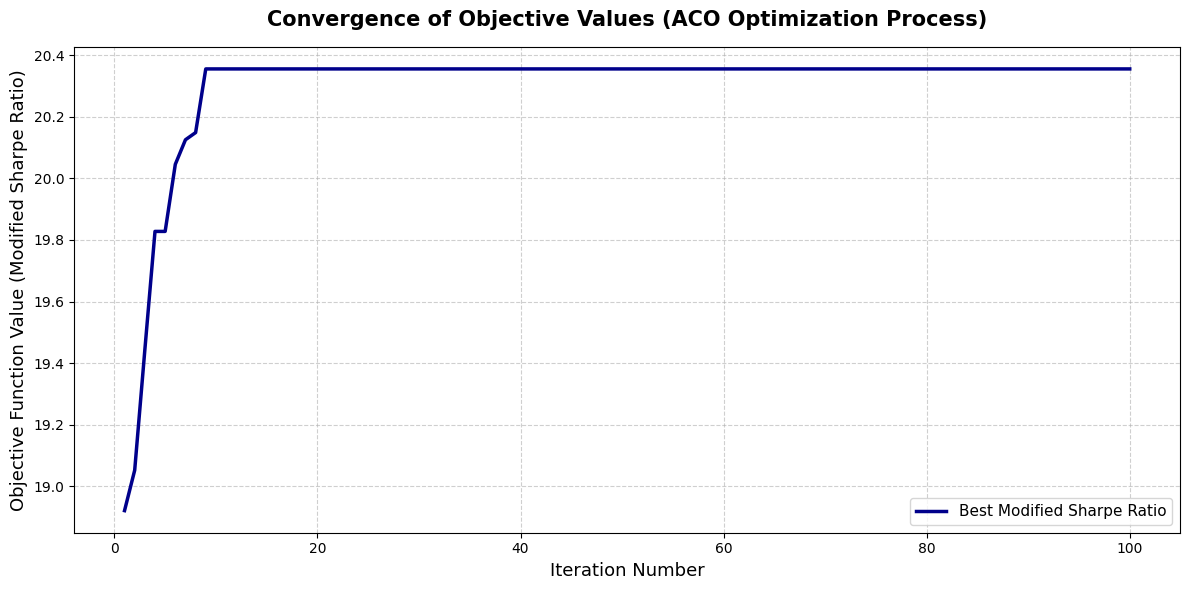

In [24]:

# --- ACO Parameters ---
num_ants = 40
max_iterations = 100
evaporation_rate = 0.1
beta = 2.0  # Influence of heuristic information
num_assets = len(tickers)

# Initialize Pheromone matrix (continuous space discretization for weights)
num_slices = 20
pheromones = np.ones((num_assets, num_slices))

# Track histories for visualization
convergence_history = []
ant_position_history = []

print("\nRunning Ant Colony Optimization...")
print("-"*80)

best_score = -np.inf
best_weights = None

for iteration in range(max_iterations):
    all_ant_weights = []
    all_ant_scores = []
    
    for ant in range(num_ants):
        # Ant constructs a portfolio choice vector
        raw_weights = np.zeros(num_assets)
        for i in range(num_assets):
            # Choose slice index based on pheromone strength
            probs = (pheromones[i] ** beta) / np.sum(pheromones[i] ** beta)
            chosen_slice = np.random.choice(num_slices, p=probs)
            raw_weights[i] = (chosen_slice + 1) / num_slices
        
        # Enforce portfolio constraints (Sum = 1)
        normalized_weights = raw_weights / np.sum(raw_weights)
        score = objective_function(normalized_weights)
        
        all_ant_weights.append(normalized_weights)
        all_ant_scores.append(score)
        
        # Track historical global best
        if score > best_score:
            best_score = score
            best_weights = normalized_weights
    
    # Record tracking metric for this iteration
    convergence_history.append(best_score)
    ant_position_history.append(all_ant_weights)
    
    # Evaporate Pheromones
    pheromones *= (1 - evaporation_rate)
    
    # Deposit Pheromones based on top-performing ants of the iteration
    top_ant_indices = np.argsort(all_ant_scores)[-5:] # Top 5 ants deposit
    for idx in top_ant_indices:
        ant_w = all_ant_weights[idx]
        for i in range(num_assets):
            slice_idx = int(min(ant_w[i] * num_slices, num_slices - 1))
            pheromones[i, slice_idx] += (all_ant_scores[idx] * 0.1)

print(f"Optimization complete! Best Modified Sharpe Ratio: {best_score:.4f}")
print("="*80)

# --- PLOT 1: Convergence of Objective Values ---
plt.figure(figsize=(12, 6))
plt.plot(range(1, max_iterations + 1), convergence_history, color='darkblue', linewidth=2.5, label='Best Modified Sharpe Ratio')
plt.title('Convergence of Objective Values (ACO Optimization Process)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Iteration Number', fontsize=13)
plt.ylabel('Objective Function Value (Modified Sharpe Ratio)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()



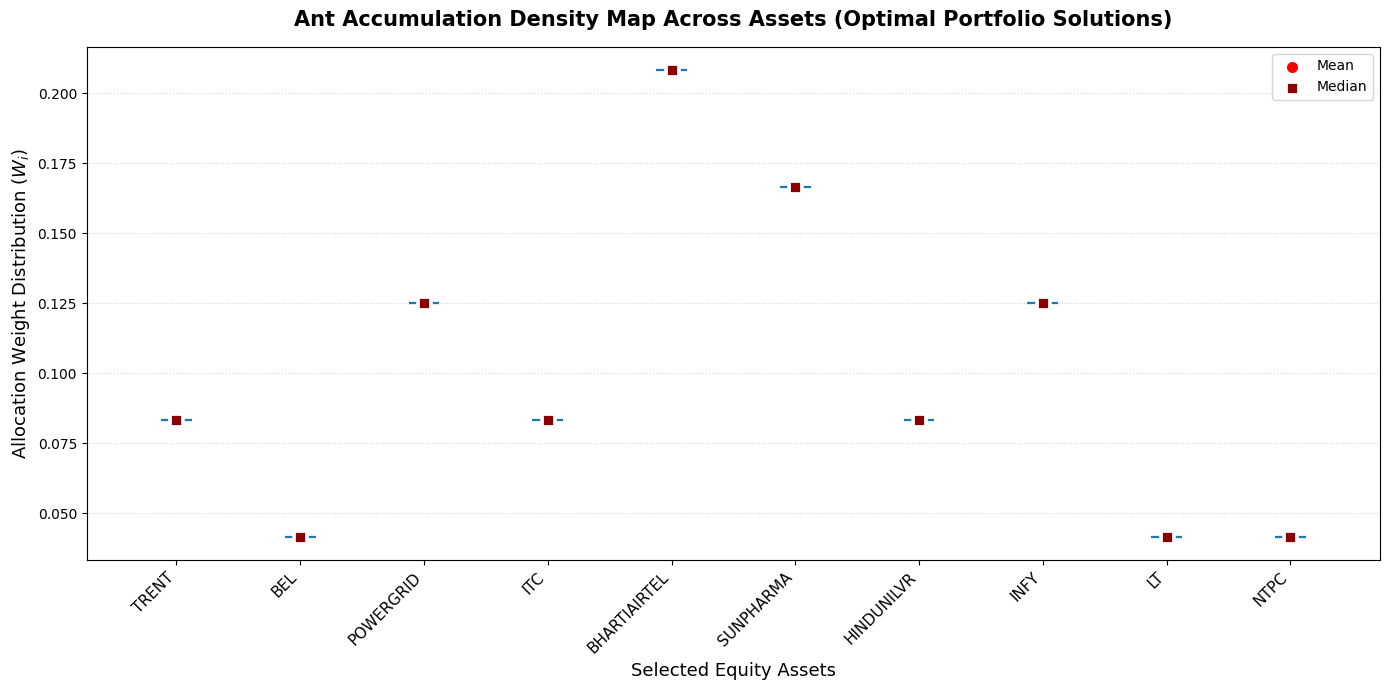

In [25]:
# --- PLOT 2: Ant Accumulation Map at Optimum Solutions ---
plt.figure(figsize=(14, 7))
# Aggregate distributions of weight allocations during final stable phase iterations
final_phase_ants = np.array(ant_position_history[-20:]) # Last 20 iterations
reshaped_ants = final_phase_ants.reshape(-1, num_assets)

# Create violin plot
violin_parts = plt.violinplot(reshaped_ants, showmeans=True, showmedians=False)

# Customize violin colors
for pc in violin_parts['bodies']:
    pc.set_facecolor('#1f77b4')
    pc.set_alpha(0.7)

# Calculate means and plot them as scatter points
means = np.mean(reshaped_ants, axis=0)
plt.scatter(range(1, num_assets + 1), means, color='red', s=100, zorder=3, 
           marker='o', edgecolors='white', linewidth=2, label='Mean')

# Also add median lines if desired
medians = np.median(reshaped_ants, axis=0)
plt.scatter(range(1, num_assets + 1), medians, color='darkred', s=80, zorder=3,
           marker='s', edgecolors='white', linewidth=2, label='Median')

plt.title('Ant Accumulation Density Map Across Assets (Optimal Portfolio Solutions)', 
          fontsize=15, fontweight='bold', pad=15)
plt.xticks(range(1, num_assets + 1), [t.split('.')[0] for t in tickers], rotation=45, ha='right', fontsize=11)
plt.xlabel('Selected Equity Assets', fontsize=13)
plt.ylabel('Allocation Weight Distribution ($W_i$)', fontsize=13)
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()



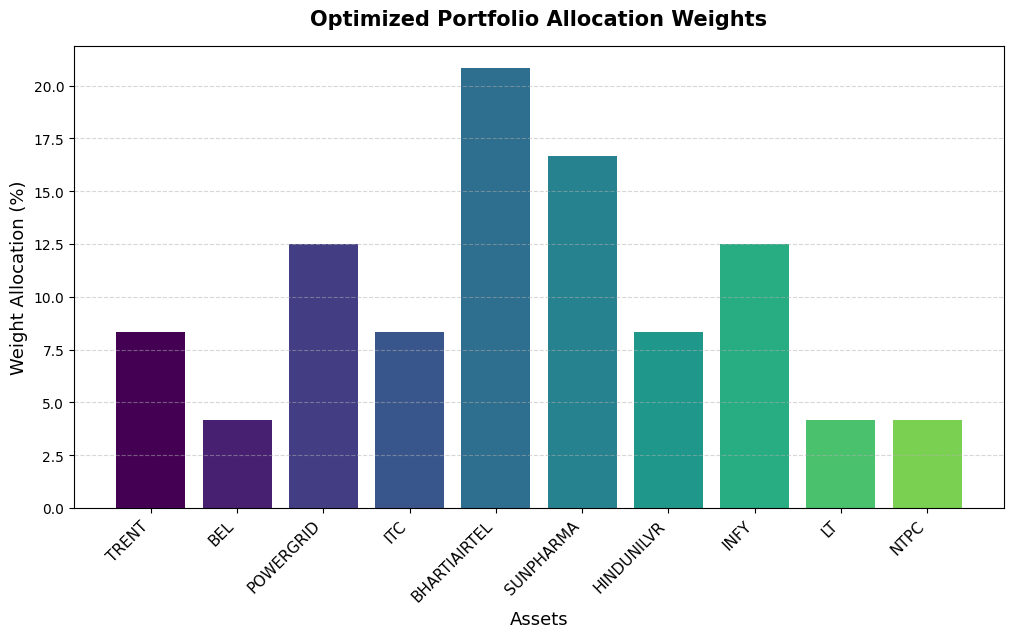

In [26]:
# --- PLOT 3: Portfolio Allocation Bar Chart ---
final_weights = best_weights / np.sum(best_weights)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(1, num_assets + 1), final_weights * 100, 
               color=plt.cm.viridis(np.linspace(0, 0.8, num_assets)))
plt.title('Optimized Portfolio Allocation Weights', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Assets', fontsize=13)
plt.ylabel('Weight Allocation (%)', fontsize=13)
plt.xticks(range(1, num_assets + 1), [t.split('.')[0] for t in tickers], rotation=45, ha='right', fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)



In [27]:


# Formulate and cleanly print your allocation table data
portfolio_df = pd.DataFrame({
    'Rank': selected_stocks['Rank'],
    'Stock/Company Name': selected_stocks['Stock'],
    'Ticker Symbol': selected_stocks['Ticker'],
    'FES Selection Score': selected_stocks['Selection Score'].round(4),
    'Optimized Weight Allocation (%)': (final_weights * 100).round(2)
})

print("\n" + "="*80)
print("PROPOSED SYSTEM PORTFOLIO OPTIMIZATION TABLE")
print("="*80)
display(portfolio_df.set_index('Rank'))
print("-"*80)
print(f"Total Portfolio Weight Sum: {portfolio_df['Optimized Weight Allocation (%)'].sum():.2f}%")
print(f"Best Modified Sharpe Ratio: {best_score:.4f}")
print("="*80)




PROPOSED SYSTEM PORTFOLIO OPTIMIZATION TABLE


,Stock/Company Name,Ticker Symbol,FES Selection Score,Optimized Weight Allocation (%)
Rank,,,,
1,Trent Ltd,TRENT.NS,0.5329,8.33
2,Bharat Electronics Ltd,BEL.NS,0.5329,4.17
3,Power Grid Corporation of India Ltd,POWERGRID.NS,0.4583,12.50
4,ITC Ltd,ITC.NS,0.4402,8.33
5,Bharti Airtel Ltd,BHARTIAIRTEL.NS,0.4196,20.83
6,Sun Pharmaceutical Industries Ltd,SUNPHARMA.NS,0.4140,16.67
7,Hindustan Unilever Ltd,HINDUNILVR.NS,0.3897,8.33
8,Infosys Ltd,INFY.NS,0.3315,12.50
9,Larsen & Toubro Ltd,LT.NS,0.3315,4.17


--------------------------------------------------------------------------------
Total Portfolio Weight Sum: 100.00%
Best Modified Sharpe Ratio: 20.3554


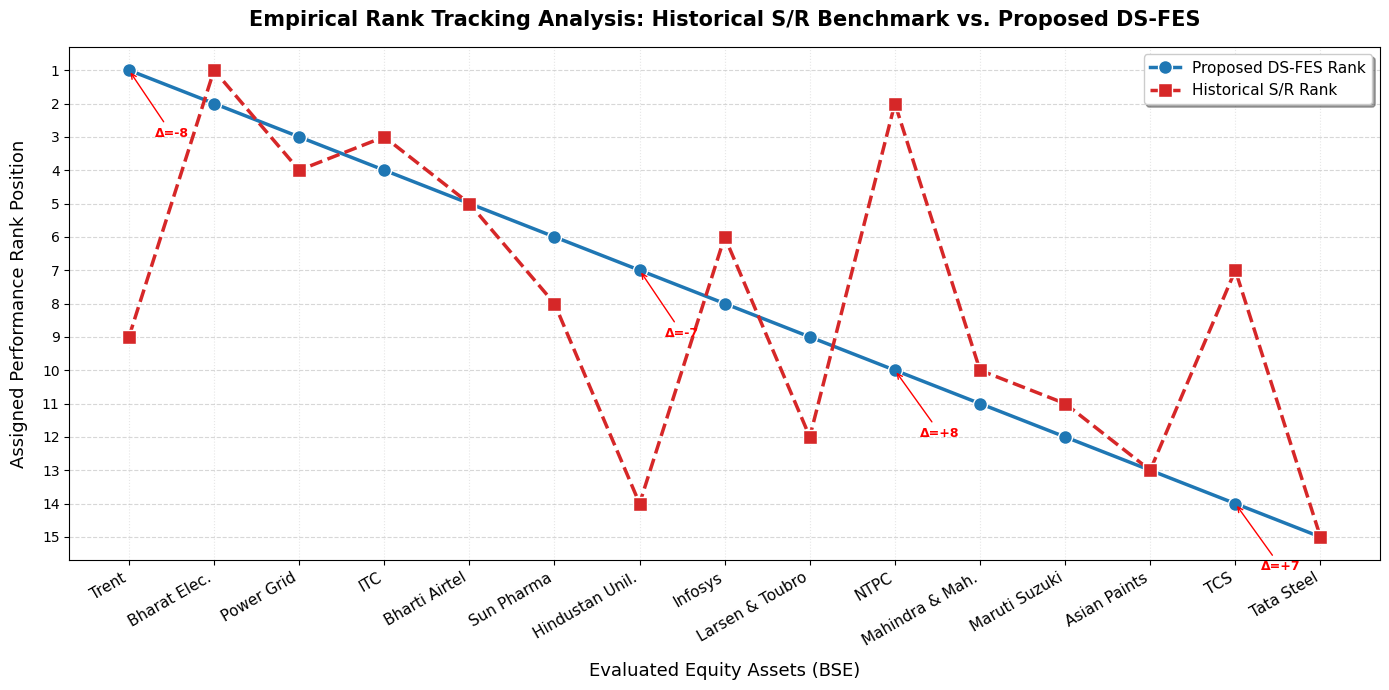

In [28]:
# --- PLOT 4: Empirical Rank Comparison Graph (Historical S/R vs Proposed Model) ---
# Reconstruct the comparative rank data matrix matching your empirical tables
comparison_data = {
    'Stock': [
        'Trent', 'Bharat Elec.', 'Power Grid', 'ITC', 'Bharti Airtel',
        'Sun Pharma', 'Hindustan Unil.', 'Infosys', 'Larsen & Toubro', 'NTPC',
        'Mahindra & Mah.', 'Maruti Suzuki', 'Asian Paints', 'TCS', 'Tata Steel'
    ],
    'Proposed DS-FES Rank': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'Historical S/R Rank':  [9, 1, 4, 3, 5, 8, 14, 6, 12, 2, 10, 11, 13, 7, 15]
}

df_plot = pd.DataFrame(comparison_data)

# Plot setup
plt.figure(figsize=(14, 7))

# Set style dynamics for the two remaining models
markers = ['o', 's']
linestyles = ['-', '--']
colors = ['#1f77b4', '#d62728']  # Professional deep blue and crimson red
columns_to_compare = ['Proposed DS-FES Rank', 'Historical S/R Rank']

# Draw tracking trajectories for both configurations
for i, col in enumerate(columns_to_compare):
    plt.plot(df_plot['Stock'], df_plot[col],
             marker=markers[i],
             linestyle=linestyles[i],
             color=colors[i],
             linewidth=2.5,
             markersize=10,
             label=col,
             markeredgecolor='white',
             markeredgewidth=1)

# Invert the Y-axis so that Rank 1 appears at the top
plt.gca().invert_yaxis()

# Fine-tune axis labels and titles for academic presentation
plt.title('Empirical Rank Tracking Analysis: Historical S/R Benchmark vs. Proposed DS-FES', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Evaluated Equity Assets (BSE)', fontsize=13, labelpad=10)
plt.ylabel('Assigned Performance Rank Position', fontsize=13, labelpad=10)

# Ensure discrete integer tick marks for ranks 1 through 15
plt.yticks(range(1, 16))
plt.xticks(rotation=30, ha='right', fontsize=11)

# Add visual separators and clean grid mapping
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.grid(True, axis='x', linestyle=':', alpha=0.3)

# Reposition the legend
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

# Add annotations for key differences
for idx, row in df_plot.iterrows():
    if abs(row['Proposed DS-FES Rank'] - row['Historical S/R Rank']) >= 5:
        stock = row['Stock']
        proposed = row['Proposed DS-FES Rank']
        historical = row['Historical S/R Rank']
        diff = proposed - historical
        y_pos = proposed
        x_pos = idx
        plt.annotate(f'Δ={diff:+d}', 
                    xy=(x_pos, y_pos),
                    xytext=(x_pos + 0.3, y_pos + 2),
                    fontsize=9,
                    color='red',
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1))

plt.tight_layout()
plt.show()



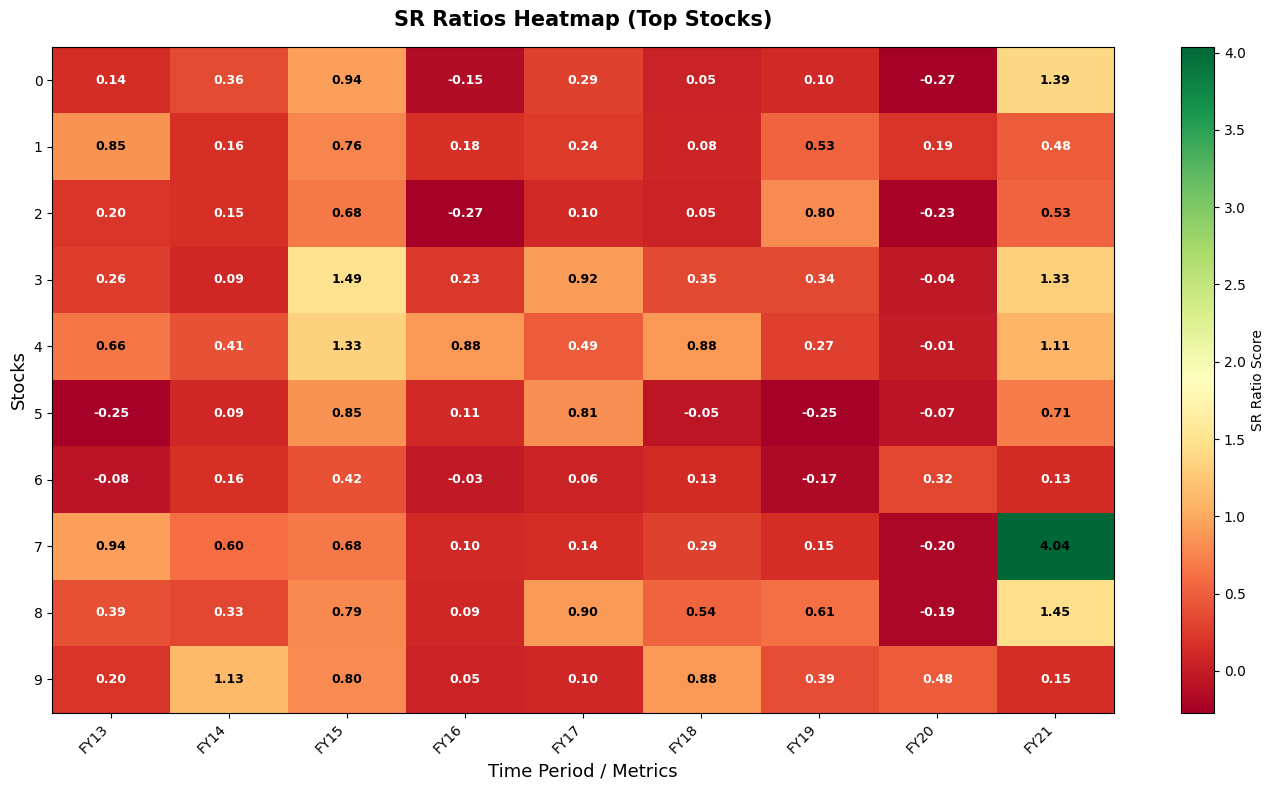


SR RATIOS DATA INFO
SR Ratios shape: (28, 14)
SR Ratios columns: ['Ticker', 'FY13', 'FY14', 'FY15', 'FY16', 'FY17', 'FY18', 'FY19', 'FY20', 'FY21']
SR Ratios first few rows:


,Ticker,FY13,FY14,FY15,FY16,FY17,FY18,FY19,FY20,FY21,FY22,FY23,FY24,FY25
0,ADANIPORTS.NS,0.139812,0.358863,0.940803,-0.145231,0.291447,0.049105,0.101484,-0.268632,1.394302,0.106038,-0.103960,1.298893,-0.257251
1,ASIANPAINT.NS,0.849446,0.164159,0.764669,0.177174,0.240616,0.082635,0.532909,0.186280,0.484144,0.472343,-0.059615,0.049402,-0.157333
2,AXISBANK.NS,0.203749,0.152410,0.684987,-0.269776,0.102699,0.053089,0.796912,-0.233012,0.533288,0.090916,0.361790,0.482594,0.050230
3,BAJAJFINSV.NS,0.261933,0.085804,1.487949,0.233733,0.919173,0.349525,0.340671,-0.044031,1.327078,1.047398,-0.169557,0.453938,0.180273
4,BAJFINANCE.NS,0.660569,0.407630,1.329244,0.881349,0.486972,0.881832,0.271166,-0.014503,1.109003,0.931838,-0.179122,0.443255,0.270492



OPTIMIZATION COMPLETE - ALL RESULTS DISPLAYED


In [29]:
# --- PLOT 5: SR Ratios Heatmap (Corrected) ---
plt.figure(figsize=(14, 8))

# Convert to numeric, coercing errors to NaN, then drop non-numeric columns
sr_numeric = sr_ratios.apply(pd.to_numeric, errors='coerce')

# Select first 10 rows and columns if available
n_rows = min(10, len(sr_numeric))
n_cols = min(10, len(sr_numeric.columns))

# Get the subset
sr_subset = sr_numeric.iloc[:n_rows, :n_cols]

# Remove any columns or rows that are all NaN
sr_subset = sr_subset.dropna(axis=1, how='all')
sr_subset = sr_subset.dropna(axis=0, how='all')

# Check if we have data to plot
if not sr_subset.empty:
    # Convert to numpy array and ensure it's float type
    heatmap_data = sr_subset.values.astype(float)
    
    # Create heatmap
    im = plt.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', interpolation='nearest')
    plt.colorbar(im, label='SR Ratio Score')
    
    plt.title('SR Ratios Heatmap (Top Stocks)', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Time Period / Metrics', fontsize=13)
    plt.ylabel('Stocks', fontsize=13)
    
    # Set tick labels
    plt.xticks(range(len(sr_subset.columns)), sr_subset.columns, rotation=45, ha='right', fontsize=10)
    plt.yticks(range(len(sr_subset.index)), sr_subset.index, fontsize=10)
    
    # Add value annotations
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            if not np.isnan(heatmap_data[i, j]):
                plt.text(j, i, f'{heatmap_data[i, j]:.2f}',
                        ha='center', va='center', color='black' if heatmap_data[i, j] > 0.5 else 'white',
                        fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Warning: No numeric data available for SR Ratios heatmap")

# Additional: Display SR Ratios data information
print("\n" + "="*80)
print("SR RATIOS DATA INFO")
print("="*80)
print(f"SR Ratios shape: {sr_ratios.shape}")
print(f"SR Ratios columns: {sr_ratios.columns.tolist()[:10]}")  # Show first 10 columns
print(f"SR Ratios first few rows:")
display(sr_ratios.head())
print("="*80)

print("\n" + "="*80)
print("OPTIMIZATION COMPLETE - ALL RESULTS DISPLAYED")
print("="*80)

In [30]:
# --- PLOT 6: Portfolio Optimization Dashboard - Treemap Visualization ---
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create a treemap for portfolio allocation
fig = go.Figure(go.Treemap(
    labels=selected_stocks['Stock'],
    parents=["Portfolio"] * len(selected_stocks),
    values=final_weights * 100,
    textinfo="label+value+percent parent",
    textposition="middle center",
    hovertemplate='<b>%{label}</b><br>Weight: %{value:.2f}%<br>Score: %{customdata:.4f}<extra></extra>',
    customdata=selected_stocks['Selection Score'],
    marker=dict(
        colors=selected_stocks['Selection Score'],
        colorscale='RdYlGn',
        showscale=True,
        colorbar=dict(title="Selection Score")
    )
))

fig.update_layout(
    title=dict(
        text='<b>Portfolio Allocation Treemap</b><br><sup>Size = Weight Allocation | Color = Selection Score</sup>',
        font=dict(size=18),
        x=0.5
    ),
    width=900,
    height=700,
    margin=dict(t=100, l=25, r=25, b=25)
)

fig.show()



In [31]:
# --- PLOT 7: Portfolio Metrics Radar Chart ---
# Normalize metrics for radar chart
metrics = {
    'Return Score': fuzzy_scores,
    'Risk Adjusted': fuzzy_scores / np.std(historical_returns, axis=1),
    'Stability': 1 / (np.std(historical_returns, axis=1) + 0.01),
    'Consistency': np.mean(historical_returns > 0, axis=1),
    'Max Drawdown': 1 / (np.abs(np.min(historical_returns, axis=1)) + 0.01)
}

# Normalize metrics to 0-1 scale for radar chart
normalized_metrics = {}
for key, values in metrics.items():
    min_val = np.min(values)
    max_val = np.max(values)
    if max_val - min_val > 0:
        normalized_metrics[key] = (values - min_val) / (max_val - min_val)
    else:
        normalized_metrics[key] = np.ones_like(values) * 0.5

# Create radar chart
fig = go.Figure()

# Add each stock as a trace
for i, stock in enumerate(selected_stocks['Stock']):
    fig.add_trace(go.Scatterpolar(
        r=[normalized_metrics[key][i] for key in metrics.keys()],
        theta=list(metrics.keys()),
        fill='toself',
        name=stock,
        opacity=0.6,
        line=dict(width=2)
    ))

# Also add portfolio average
avg_metrics = [np.mean([normalized_metrics[key][i] for i in range(len(selected_stocks))]) 
               for key in metrics.keys()]
fig.add_trace(go.Scatterpolar(
    r=avg_metrics,
    theta=list(metrics.keys()),
    fill='toself',
    name='Portfolio Average',
    line=dict(color='red', width=3, dash='dash'),
    opacity=0.8
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickfont=dict(size=10)
        ),
        angularaxis=dict(
            tickfont=dict(size=12, weight='bold')
        )
    ),
    title=dict(
        text='<b>Stock Performance Metrics Radar Chart</b>',
        font=dict(size=18),
        x=0.5
    ),
    width=900,
    height=700,
    showlegend=True,
    legend=dict(
        x=1.1,
        y=0.5,
        font=dict(size=10)
    )
)

fig.show()



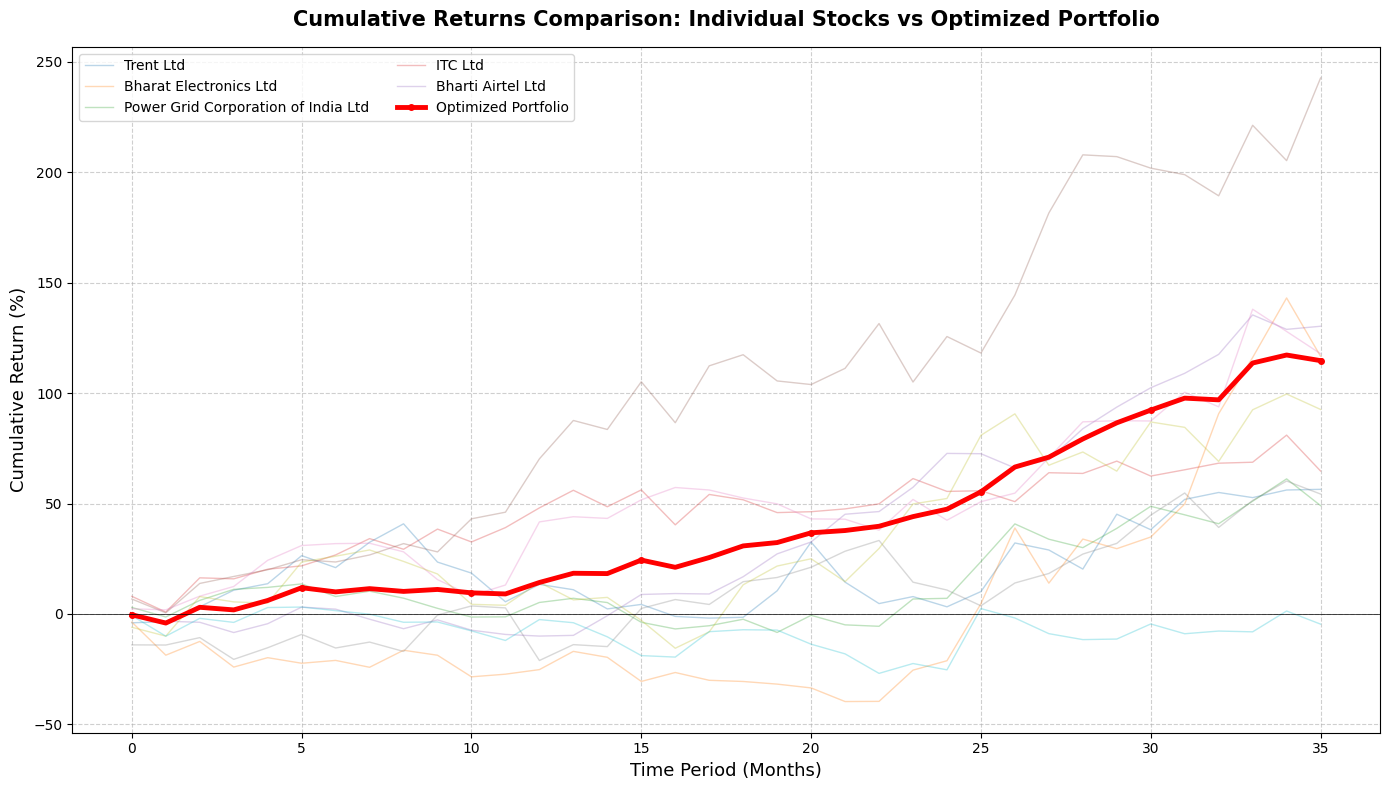

In [32]:
# --- PLOT 8: Cumulative Returns Comparison ---
# Calculate cumulative returns for each stock
cumulative_returns = []
for i in range(len(tickers)):
    cum_ret = np.cumprod(1 + historical_returns[i]) - 1
    cumulative_returns.append(cum_ret)

# Calculate portfolio cumulative returns
portfolio_cum_ret = np.cumprod(1 + np.dot(final_weights, historical_returns)) - 1

plt.figure(figsize=(14, 8))

# Plot individual stock cumulative returns with lower opacity
for i, stock in enumerate(selected_stocks['Stock']):
    plt.plot(range(len(cumulative_returns[i])), cumulative_returns[i] * 100, 
             alpha=0.3, linewidth=1, label=stock if i < 5 else "")

# Plot portfolio cumulative return with bold line
plt.plot(range(len(portfolio_cum_ret)), portfolio_cum_ret * 100, 
         color='red', linewidth=3.5, label='Optimized Portfolio', 
         marker='o', markersize=4, markevery=5)

plt.title('Cumulative Returns Comparison: Individual Stocks vs Optimized Portfolio', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Time Period (Months)', fontsize=13)
plt.ylabel('Cumulative Return (%)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=10, ncol=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()



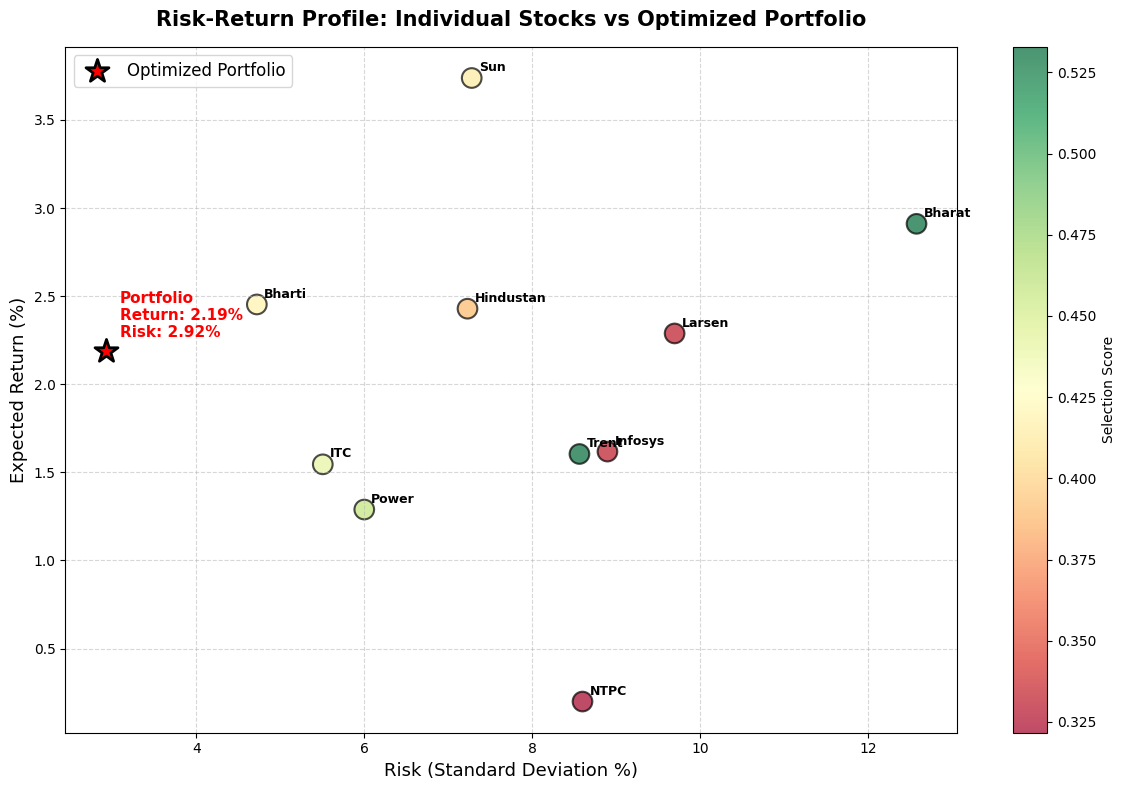

In [33]:
# --- PLOT 9: Portfolio Risk-Return Scatter ---
# Calculate individual stock risk and return
stock_returns = np.mean(historical_returns, axis=1) * 100
stock_risks = np.std(historical_returns, axis=1) * 100

# Calculate portfolio risk and return
port_return = np.mean(np.dot(final_weights, historical_returns)) * 100
port_risk = np.std(np.dot(final_weights, historical_returns)) * 100

plt.figure(figsize=(12, 8))

# Plot individual stocks
scatter = plt.scatter(stock_risks, stock_returns, 
                     c=selected_stocks['Selection Score'], 
                     cmap='RdYlGn', s=200, alpha=0.7,
                     edgecolors='black', linewidth=1.5)

# Add stock labels
for i, stock in enumerate(selected_stocks['Stock']):
    plt.annotate(stock.split()[0], 
                (stock_risks[i], stock_returns[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

# Plot portfolio
plt.scatter(port_risk, port_return, color='red', s=300, 
           marker='*', edgecolors='black', linewidth=2,
           label='Optimized Portfolio', zorder=5)

# Add text annotation for portfolio
plt.annotate(f'Portfolio\nReturn: {port_return:.2f}%\nRisk: {port_risk:.2f}%',
            (port_risk, port_return),
            xytext=(10, 10), textcoords='offset points',
            fontsize=11, fontweight='bold', color='red')

plt.colorbar(scatter, label='Selection Score')
plt.xlabel('Risk (Standard Deviation %)', fontsize=13)
plt.ylabel('Expected Return (%)', fontsize=13)
plt.title('Risk-Return Profile: Individual Stocks vs Optimized Portfolio', 
          fontsize=15, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()



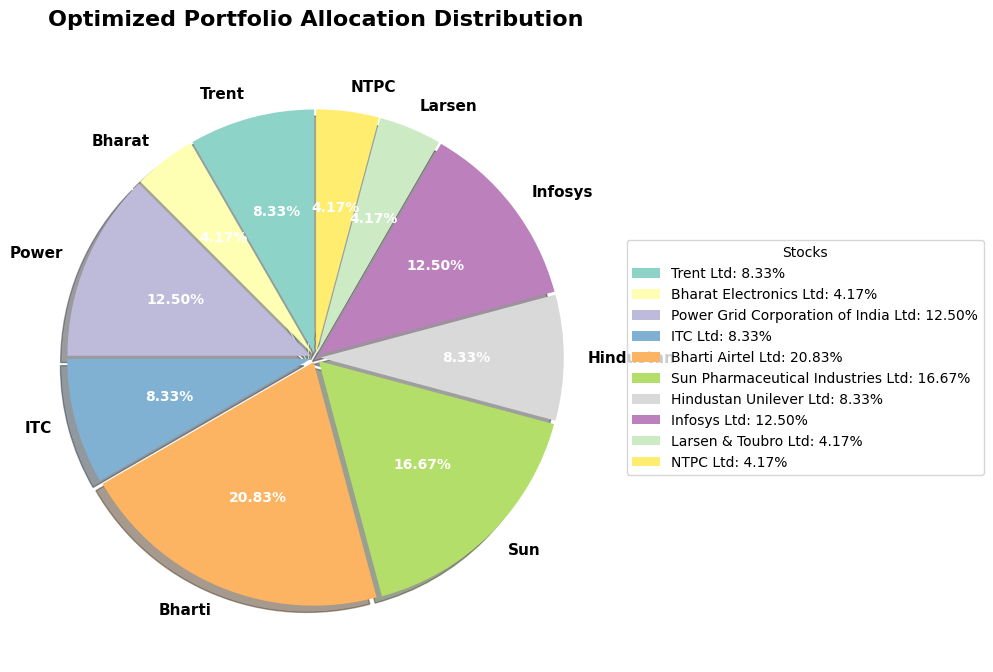


ADDITIONAL PORTFOLIO VISUALIZATIONS COMPLETE


In [34]:
# --- PLOT 10: Portfolio Allocation Pie Chart ---
plt.figure(figsize=(10, 10))

# Create pie chart with customized colors
colors = plt.cm.Set3(np.linspace(0, 1, num_assets))
wedges, texts, autotexts = plt.pie(final_weights * 100, 
                                    labels=[stock.split()[0] for stock in selected_stocks['Stock']],
                                    autopct=lambda pct: f'{pct:.2f}%' if pct > 1 else '',
                                    colors=colors,
                                    startangle=90,
                                    explode=[0.02] * num_assets,
                                    shadow=True,
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})

# Customize autopct text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.title('Optimized Portfolio Allocation Distribution', 
          fontsize=16, fontweight='bold', pad=20)

# Add a legend with more detail
plt.legend(wedges, [f"{stock}: {weight:.2f}%" for stock, weight in 
                    zip(selected_stocks['Stock'], final_weights * 100)],
          title="Stocks", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ADDITIONAL PORTFOLIO VISUALIZATIONS COMPLETE")
print("="*80)